<a href="https://colab.research.google.com/github/Aaaaddddyyyyyyyy/Deep-Learning/blob/main/Early_stopping.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as trf
import numpy as np
import pandas as pd
from pylab import rcParams
import matplotlib.pyplot as plt
import warnings
import seaborn as sns

from mlxtend.plotting import plot_decision_regions
from matplotlib.colors import ListedColormap
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_circles

In [2]:
X,y= make_circles(n_samples=100, noise=0.1,random_state=42)

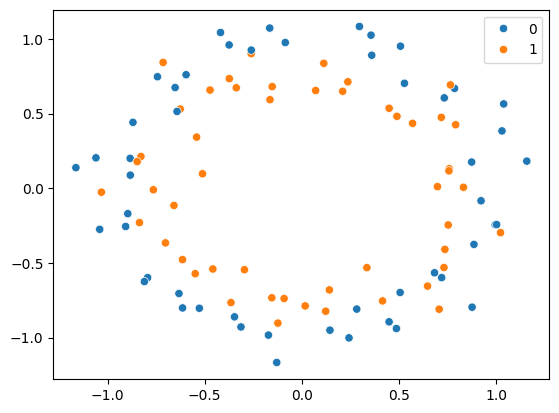

In [3]:
sns.scatterplot(x=X[:,0],y=X[:,1],hue=y)
plt.show()

In [4]:
X_train,X_test,y_train,y_test=train_test_split(X,y, test_size=0.2,random_state=42)

In [5]:
model=Sequential()

model.add(Dense(256,input_dim=2,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [6]:
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 13s 1ms/step


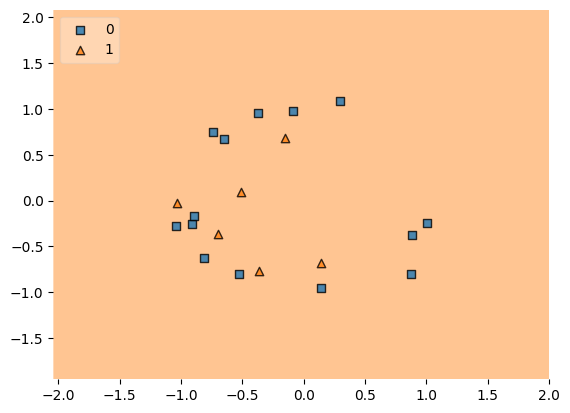

In [7]:
plot_decision_regions(X_test,y_test.ravel(),clf=model, legend=2)
plt.show()

Early Stopping

In [8]:
model=Sequential()

model.add(Dense(256,input_dim=2,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

In [9]:
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [10]:
callabck= EarlyStopping(
    monitor='val_loss',
    min_delta=0.0001,
    patience=20,
    verbose=1,
    mode='auto',
    baseline=None,
    restore_best_weights=False
)

In [12]:
history=model.fit(X_train,y_train,validation_data=(X_test,y_test),epochs=3500,callbacks=callabck)     ## stops when the best output is achieve

Epoch 1/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 115ms/step - accuracy: 0.4375 - loss: 0.6956 - val_accuracy: 0.6500 - val_loss: 0.6921
Epoch 2/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.5625 - loss: 0.6935 - val_accuracy: 0.3500 - val_loss: 0.6995
Epoch 3/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.5875 - loss: 0.6916 - val_accuracy: 0.3000 - val_loss: 0.7019
Epoch 4/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.5500 - loss: 0.6910 - val_accuracy: 0.3000 - val_loss: 0.7062
Epoch 5/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.5500 - loss: 0.6903 - val_accuracy: 0.3000 - val_loss: 0.7092
Epoch 6/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.5500 - loss: 0.6891 - val_accuracy: 0.3000 - val_loss: 0.7099
Epoch 7/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.5500 - loss: 0.6891 - val_accuracy: 0.3000 - val_loss: 0.7113
Epoch 8/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.5500 - loss: 0.6879 - val_accuracy: 0.3000 - 

<function matplotlib.pyplot.show(close=None, block=None)>

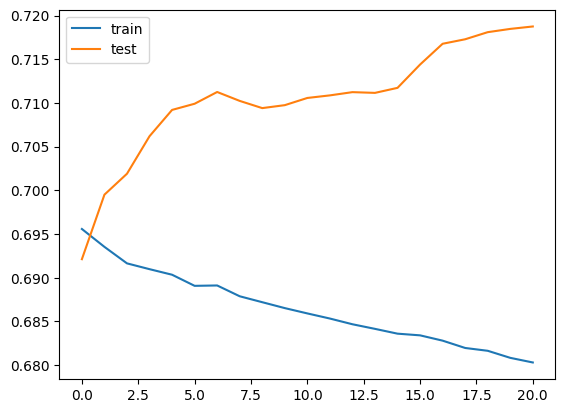

In [14]:
plt.plot(history.history['loss'],label='train')
plt.plot(history.history['val_loss'],label='test')
plt.legend()
plt.show

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 13s 1ms/step


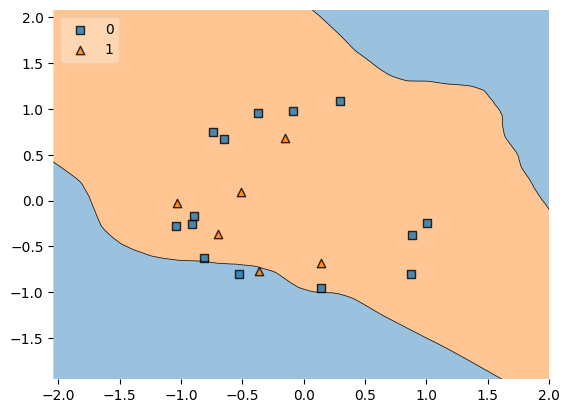

In [15]:
plot_decision_regions(X_test,y_test.ravel(),clf=model,legend=2)
plt.show()